<h1><b>Configuración y librerías

In [1]:
# Librerías
import torch
import numpy as np
import random
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, recall_score, precision_score)
from torchvision.models import efficientnet_b0

In [2]:
# Rutas
DATOS_DIR = Path("../preprocesamiento/output/center_3/preprocesamiento_train")
TEST_DIR = Path("../preprocesamiento/output/center_3/preprocesamiento_test")

# Uso GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# HIPERPARÁMETROS
BATCH_SIZE = 16      # imágenes por batch
EPOCHS     = 30      # número de épocas
LR         = 0.0004    # learning rate
VAL_SPLIT  = 0.2     # 20% para validación

Dispositivo: cuda


In [3]:
# Semilla para reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

<h1><b>Dataset

In [4]:
# P0003_S0033_STROKE.npy label = 1
# P0002_S0027_CONTROL.npy label = 0

class StrokeDataset(Dataset):

    def __init__(self, archivos):
        self.archivos = archivos

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta = self.archivos[idx]

        # Cargar imagen preprocesada shape (2, 112, 112)
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        # Extraer etiqueta del nombre del archivo
        nombre = ruta.stem
        if "STROKE" in nombre:
            label = 1
        else:
            label = 0

        return imagen, torch.tensor(label, dtype=torch.float32)
    

# Verifación
todos_los_archivos = sorted(DATOS_DIR.glob("*.npy"))

print(f"Total archivos : {len(todos_los_archivos)}")

strokes   = sum(1 for f in todos_los_archivos if "STROKE"  in f.stem)
controles = sum(1 for f in todos_los_archivos if "CONTROL" in f.stem)
print(f"STROKE         : {strokes}")
print(f"CONTROL        : {controles}")

dataset_prueba = StrokeDataset(todos_los_archivos)
imagen, label  = dataset_prueba[0]
print(f"\nEjemplo cargado:")
print(f"  Shape  : {imagen.shape}")
print(f"  Label  : {label.item()} ({'STROKE' if label.item()==1 else 'CONTROL'})")

Total archivos : 679
STROKE         : 427
CONTROL        : 252

Ejemplo cargado:
  Shape  : torch.Size([2, 112, 112])
  Label  : 0.0 (CONTROL)


<h1><b>Split y DataLoader

In [5]:
total    = len(todos_los_archivos)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

archivos_train, archivos_val = random_split(
    todos_los_archivos,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Convertir a lista para pasarlos al Dataset
archivos_train = [todos_los_archivos[i] for i in archivos_train.indices]
archivos_val   = [todos_los_archivos[i] for i in archivos_val.indices]

# Dataset
dataset_train = StrokeDataset(archivos_train)
dataset_val   = StrokeDataset(archivos_val)

# DataLoader
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)

# Verificación
print(f"Train : {len(dataset_train)} muestras | {len(loader_train)} batches")
print(f"Val   : {len(dataset_val)}  muestras | {len(loader_val)} batches")

imagenes, labels = next(iter(loader_train))
print(f"\nBatch de prueba:")
print(f"  Imágenes : {imagenes.shape}")
print(f"  Labels   : {labels.shape} | {labels}")

Train : 544 muestras | 34 batches
Val   : 135  muestras | 9 batches

Batch de prueba:
  Imágenes : torch.Size([16, 2, 112, 112])
  Labels   : torch.Size([16]) | tensor([0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.])


<h1> <b> Modelo de entrenamiento

In [6]:
# Qué canales importan más
class ChannelAttention(nn.Module):
    def __init__(self, canales, reduccion=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(canales, canales // reduccion),
            nn.ReLU(),
            nn.Linear(canales // reduccion, canales)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.mlp(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x

# Qué zonas de la imagen importan más
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_ = x.max(dim=1, keepdim=True).values
        mapa = torch.cat([avg, max_], dim=1)
        return self.sigmoid(self.conv(mapa)) * x


class CBAM(nn.Module):
    def __init__(self, canales):
        super().__init__()
        self.channel = ChannelAttention(canales)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

In [7]:
# Arquitectura ResNet-18 con CBAM
class ResNet18CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18 base
        base = resnet18(weights=None)

        # Primera capa: 3 canales a 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Guardamos las capas de ResNet
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        # CBAM después de cada capa residual
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        # Clasificador final: 1 neurona para STROKE/CONTROL
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.cbam4(self.layer4(x))

        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x

In [8]:
modelo = ResNet18CBAM().to(DEVICE)

# Pasar un batch de prueba
with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())

print(f"Entrada : {imagenes.shape}")
print(f"Salida  : {salida.shape}")
print(f"Parámetros totales: {total_params:,}")

Entrada : torch.Size([16, 2, 112, 112])
Salida  : torch.Size([16, 1])
Parámetros totales: 11,218,825


<h1><b> Entrenamiento

In [9]:
# Focal Loss para center_3
# Para center_3 — confundido en ambas clases
# gamma controla cuánto se enfoca en ejemplos difíciles
# gamma=2 es el estándar de la literatura
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        loss  = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

In [10]:
criterio  = FocalLoss(gamma=2.0)          # Loss para clasificación binaria
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Early stopping
PACIENCIA        = 7      # épocas sin mejora antes de parar
mejor_val_loss   = float("inf")
epocas_sin_mejora = 0
mejor_modelo     = None

# Ruta donde guardar el mejor modelo
MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "resnet18_cbam_center3_focal.pth"

# Loop de entrenamiento
historial = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # TRAIN
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()

        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # VALIDACIÓN
    modelo.eval()
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            salida  = modelo(imagenes)
            loss    = criterio(salida, labels)

            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    # METRICAS
    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)

    scheduler.step()

    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    # GUARDAR MEJOR MODELO
    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")

    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    # EARLY STOPPING
    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

Época 01/30 | Train loss: 0.1344 acc: 0.7206 | Val loss: 1.0602 acc: 0.6444 | 2.2s
  ✔ Mejor modelo guardado (val_loss: 1.0602)
Época 02/30 | Train loss: 0.0744 acc: 0.8732 | Val loss: 0.1259 acc: 0.8370 | 1.6s
  ✔ Mejor modelo guardado (val_loss: 0.1259)
Época 03/30 | Train loss: 0.0611 acc: 0.8971 | Val loss: 0.1057 acc: 0.8444 | 1.6s
  ✔ Mejor modelo guardado (val_loss: 0.1057)
Época 04/30 | Train loss: 0.0381 acc: 0.9430 | Val loss: 0.1170 acc: 0.8148 | 1.6s
  Sin mejora 1/7
Época 05/30 | Train loss: 0.0341 acc: 0.9485 | Val loss: 0.1025 acc: 0.8444 | 1.6s
  ✔ Mejor modelo guardado (val_loss: 0.1025)
Época 06/30 | Train loss: 0.0306 acc: 0.9504 | Val loss: 0.0930 acc: 0.8444 | 1.6s
  ✔ Mejor modelo guardado (val_loss: 0.0930)
Época 07/30 | Train loss: 0.0403 acc: 0.9449 | Val loss: 0.1322 acc: 0.8667 | 1.6s
  Sin mejora 1/7
Época 08/30 | Train loss: 0.0106 acc: 0.9871 | Val loss: 0.1402 acc: 0.8519 | 1.6s
  Sin mejora 2/7
Época 09/30 | Train loss: 0.0068 acc: 0.9926 | Val loss: 0.1

<h1> <b> Evaluación

In [11]:
archivos_test = sorted(TEST_DIR.glob("*.npy"))

print(f"Total test : {len(archivos_test)}")
print(f"STROKE     : {sum(1 for f in archivos_test if 'STROKE'  in f.stem)}")
print(f"CONTROL    : {sum(1 for f in archivos_test if 'CONTROL' in f.stem)}")

# Dataset y loader
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

# Cargar el mejor modelo
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)

print("RESULTADOS — VALIDACIÓN")

print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

Total test : 171
STROKE     : 107
CONTROL    : 64
RESULTADOS — VALIDACIÓN
  AUC-ROC       : 0.6330
  Accuracy      : 0.5614
  F1-Score      : 0.5856
  Sensibilidad  : 0.4953  (detecta STROKE)
  Especificidad : 0.6719  (detecta CONTROL)
  Precisión     : 0.7162


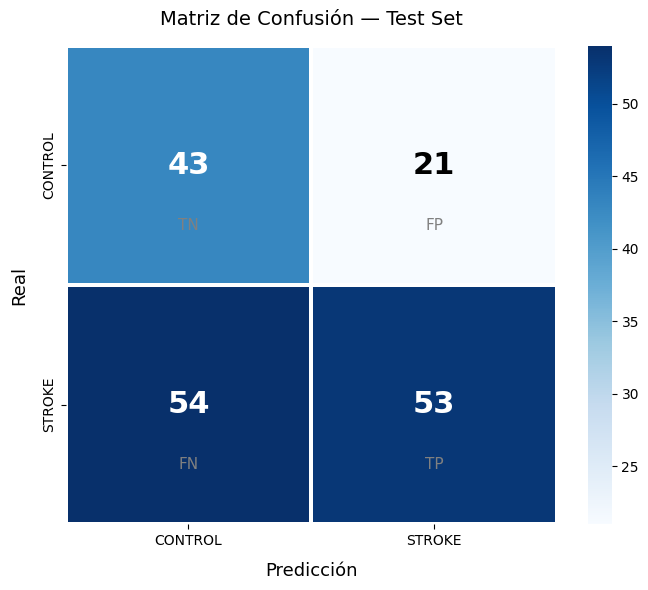

In [12]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h1><b> Entrenamiento sin CBAM

In [15]:
class ResNet18Base(nn.Module):
    def __init__(self):
        super().__init__()

        base = resnet18(weights=None)

        # Modificamos la primera capa: 3 canales - 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x


# Verificación
modelo_base = ResNet18Base().to(DEVICE)

with torch.no_grad():
    salida = modelo_base(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Entrada    : {imagenes.shape}")
print(f"Salida     : {salida.shape}")
print(f"Parámetros : {total_params:,}")

Entrada    : torch.Size([7, 2, 112, 112])
Salida     : torch.Size([7, 1])
Parámetros : 11,173,889


In [16]:
# ENTRENAMIENTO — ResNet18 SIN CBAM
criterio  = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(modelo_base.parameters(), lr=LR)  # ← modelo_base
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_loss    = float("inf")
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_PATH_BASE = MODELO_DIR / "resnet18_base_mejor.pth"  # nombre distinto

historial_base = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    modelo_base.train()  # ← modelo_base
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo_base(imagenes)  # ← modelo_base
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    modelo_base.eval()  # ← modelo_base
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo_base(imagenes)  # modelo_base
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial_base["train_loss"].append(train_loss)
    historial_base["val_loss"].append(val_loss)
    historial_base["train_acc"].append(train_acc)
    historial_base["val_acc"].append(val_acc)

    scheduler.step()
    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo_base.state_dict())
        torch.save(mejor_modelo, MODELO_PATH_BASE)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH_BASE}")

Época 01/30 | Train loss: 0.1737 acc: 0.6489 | Val loss: 0.3973 acc: 0.6444 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.3973)
Época 02/30 | Train loss: 0.0832 acc: 0.8750 | Val loss: 0.1703 acc: 0.7333 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.1703)
Época 03/30 | Train loss: 0.0771 acc: 0.8548 | Val loss: 0.1175 acc: 0.7926 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.1175)
Época 04/30 | Train loss: 0.0186 acc: 0.9761 | Val loss: 0.1480 acc: 0.8000 | 1.5s
  Sin mejora 1/7
Época 05/30 | Train loss: 0.0547 acc: 0.9136 | Val loss: 0.1014 acc: 0.8296 | 1.5s
  ✔ Mejor modelo guardado (val_loss: 0.1014)
Época 06/30 | Train loss: 0.0319 acc: 0.9577 | Val loss: 0.1343 acc: 0.8148 | 1.5s
  Sin mejora 1/7
Época 07/30 | Train loss: 0.0236 acc: 0.9779 | Val loss: 0.1997 acc: 0.7926 | 1.5s
  Sin mejora 2/7
Época 08/30 | Train loss: 0.0407 acc: 0.9375 | Val loss: 0.2764 acc: 0.7333 | 1.5s
  Sin mejora 3/7
Época 09/30 | Train loss: 0.0405 acc: 0.9357 | Val loss: 0.3971 acc: 0.7407 | 1.5s
  Sin

In [17]:
# Cargar el mejor modelo base
modelo_base.load_state_dict(torch.load(MODELO_PATH_BASE, map_location=DEVICE))  # ← base
modelo_base.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_base(imagenes)  # ← base
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print(" RESULTADOS — TEST SET (Sin CBAM)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")


 RESULTADOS — TEST SET (Sin CBAM)
  AUC-ROC       : 0.6167
  Accuracy      : 0.5906
  F1-Score      : 0.6465
  Sensibilidad  : 0.5981  (detecta STROKE)
  Especificidad : 0.5781  (detecta CONTROL)
  Precisión     : 0.7033


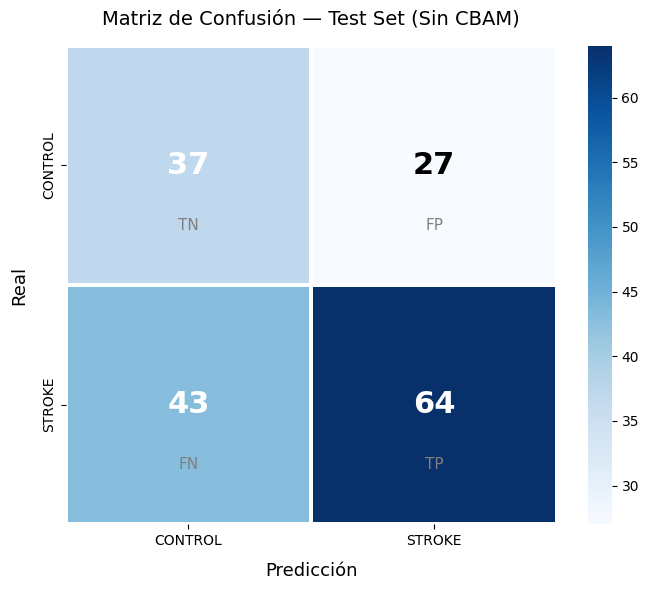

In [18]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set (Sin CBAM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# **Efficent-B0**

In [24]:
class EfficientNetB0CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        base = efficientnet_b0(weights=None)

        # Primera capa: 3 canales a 2 canales (DWI + ADC)
        base.features[0][0] = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1, bias=False)

        self.features = base.features

        # CBAM al final del extractor de características
        self.cbam = CBAM(1280)  # EfficientNet-B0 termina en 1280 canales

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x


# Verificación
modelo = EfficientNetB0CBAM().to(DEVICE)

with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Entrada    : {imagenes.shape}")
print(f"Salida     : {salida.shape}")
print(f"Parámetros : {total_params:,}")

Entrada    : torch.Size([11, 2, 112, 112])
Salida     : torch.Size([11, 1])
Parámetros : 4,214,800


<h2><b> Entrenamiento

In [25]:
criterio  = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_loss    = float("inf")
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "efficientnet_cbam_mejor.pth"  # ← nombre distinto

historial = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    modelo.eval()
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo(imagenes)
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)

    scheduler.step()
    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

Época 01/30 | Train loss: 0.6008 acc: 0.6471 | Val loss: 0.6871 acc: 0.6444 | 2.2s
  ✔ Mejor modelo guardado (val_loss: 0.6871)
Época 02/30 | Train loss: 0.4185 acc: 0.7996 | Val loss: 0.7714 acc: 0.3556 | 2.1s
  Sin mejora 1/7
Época 03/30 | Train loss: 0.3304 acc: 0.8603 | Val loss: 0.7171 acc: 0.6889 | 2.1s
  Sin mejora 2/7
Época 04/30 | Train loss: 0.2897 acc: 0.8732 | Val loss: 0.6890 acc: 0.6444 | 2.1s
  Sin mejora 3/7
Época 05/30 | Train loss: 0.1871 acc: 0.9338 | Val loss: 0.7269 acc: 0.7259 | 2.1s
  Sin mejora 4/7
Época 06/30 | Train loss: 0.1784 acc: 0.9320 | Val loss: 0.5531 acc: 0.7704 | 2.1s
  ✔ Mejor modelo guardado (val_loss: 0.5531)
Época 07/30 | Train loss: 0.1169 acc: 0.9669 | Val loss: 0.4984 acc: 0.7630 | 2.1s
  ✔ Mejor modelo guardado (val_loss: 0.4984)
Época 08/30 | Train loss: 0.1101 acc: 0.9467 | Val loss: 0.7549 acc: 0.7778 | 2.1s
  Sin mejora 1/7
Época 09/30 | Train loss: 0.0782 acc: 0.9761 | Val loss: 0.6677 acc: 0.7778 | 2.1s
  Sin mejora 2/7
Época 10/30 | Tr

<h2> <b> Evaluación

In [26]:
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Dataset y loader
archivos_test = sorted(TEST_DIR.glob("*.npy"))
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print("   RESULTADOS — TEST (EfficientNet-B0)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

   RESULTADOS — TEST (EfficientNet-B0)
  AUC-ROC       : 0.4492
  Accuracy      : 0.4094
  F1-Score      : 0.3952
  Sensibilidad  : 0.3084  (detecta STROKE)
  Especificidad : 0.5781  (detecta CONTROL)
  Precisión     : 0.5500


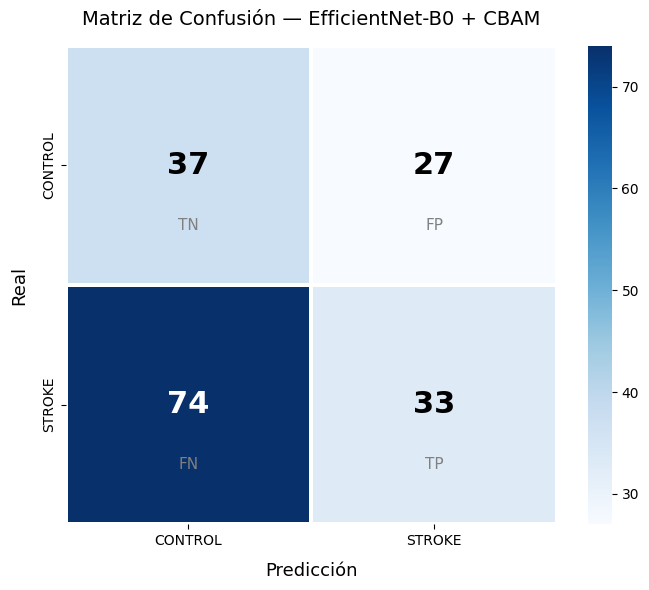

In [27]:
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — EfficientNet-B0 + CBAM", fontsize=14, pad=15)
plt.tight_layout()
plt.show()